In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
# ── Plot Styling ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
COLORS = {'churn': '#E74C3C', 'no_churn': '#2ECC71', 'accent': '#3498DB',
          'high': '#E74C3C', 'medium': '#F39C12', 'low': '#2ECC71'}

print("✅ All libraries imported successfully!")
print(f"   pandas  {pd.__version__}  |  numpy  {np.__version__}")
import sklearn, matplotlib, seaborn
print(f"   sklearn {sklearn.__version__}  |  matplotlib {matplotlib.__version__}  |  seaborn {seaborn.__version__}")


✅ All libraries imported successfully!
   pandas  2.3.3  |  numpy  2.3.5
   sklearn 1.7.2  |  matplotlib 3.10.6  |  seaborn 0.13.2


In [2]:
# ─── SECTION 2: DATA LOADING ─────────────────────────────────────────────────
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("=" * 55)
print("         TELCO CUSTOMER CHURN DATASET OVERVIEW")
print("=" * 55)
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print(f"  Churned : {(df['Churn'] == 'Yes').sum():,}  ({(df['Churn']=='Yes').mean()*100:.1f}%)")
print(f"  Retained: {(df['Churn'] == 'No').sum():,}  ({(df['Churn']=='No').mean()*100:.1f}%)")
print("=" * 55)

         TELCO CUSTOMER CHURN DATASET OVERVIEW
  Rows    : 7,043
  Columns : 21
  Churned : 1,869  (26.5%)
  Retained: 5,174  (73.5%)


In [3]:
# ── First Look ──────────────────────────────────────────────────────────────
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
 #Data Types & Structure ──────────────────────────────────────────────────
print("Column Info:")
print("-" * 45)
df.info()

Column Info:
---------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-nul

In [5]:
# ── Summary Statistics ──────────────────────────────────────────────────────
print("Numeric Column Statistics:")
df.describe().round(2)

Numeric Column Statistics:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [6]:
# ── Missing Values Check ────────────────────────────────────────────────────
print("Missing / Null Values per Column:")
print("-" * 35)
nulls = df.isnull().sum()
blanks = (df == ' ').sum()
missing_report = pd.DataFrame({'Nulls': nulls, 'Blank Strings': blanks})
missing_report = missing_report[missing_report.sum(axis=1) > 0]
if missing_report.empty:
    print("  No null values found.")
    print(f"  Blank string cells in TotalCharges: {(df['TotalCharges'] == ' ').sum()}")
else:
    print(missing_report)

Missing / Null Values per Column:
-----------------------------------
              Nulls  Blank Strings
TotalCharges      0             11


In [7]:
#DATA CLEANING ────────────────────────────────────────────────
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
missing_tc = df['TotalCharges'].isnull().sum()
print(f"TotalCharges: {missing_tc} rows converted to NaN (were blank strings).")

# Fill NaN with median (these are mostly new customers with tenure=0)
median_tc = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_tc, inplace=True)
print(f"  → Filled with median: ${median_tc:.2f}")

# ── Encode Target Variable ───────────────────────────────────────────────────
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)
print(f"\\nChurn_Binary created  →  0 = No Churn, 1 = Churned")
print(df['Churn_Binary'].value_counts().to_string())


TotalCharges: 11 rows converted to NaN (were blank strings).
  → Filled with median: $1397.47
\nChurn_Binary created  →  0 = No Churn, 1 = Churned
Churn_Binary
0    5174
1    1869


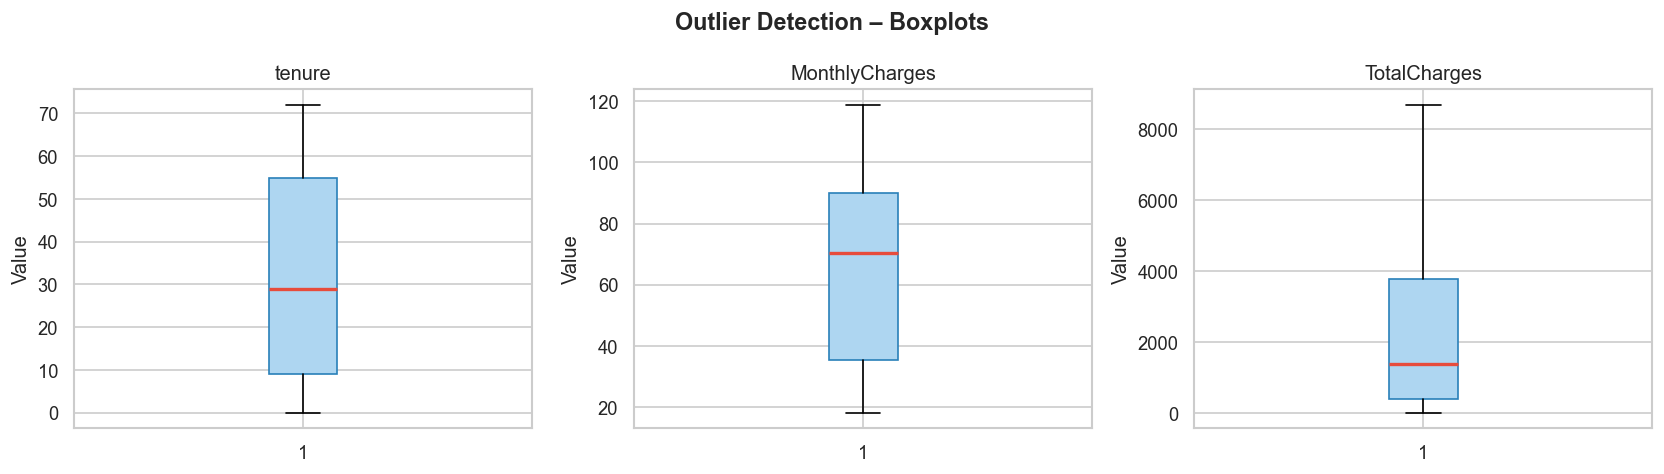

No extreme outliers found. All values are within expected business range.


In [8]:
# ── Outlier Check on Numeric Columns ────────────────────────────────────────
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Outlier Detection – Boxplots', fontsize=14, fontweight='bold')

for ax, col in zip(axes, num_cols):
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor='#AED6F1', color='#2980B9'),
               medianprops=dict(color='#E74C3C', linewidth=2))
    ax.set_title(col)
    ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig('outlier_boxplots.png', bbox_inches='tight')
plt.show()
print("No extreme outliers found. All values are within expected business range.")

In [9]:

# ─── SECTION 4: FEATURE ENGINEERING ─────────────────────────────────────────
def tenure_group(t):
    if t <= 12:   return 'New (0–12m)'
    elif t <= 36: return 'Mid (13–36m)'
    else:          return 'Long-term (36m+)'

df['Tenure_Group'] = df['tenure'].apply(tenure_group)
print("Tenure_Group distribution:")
print(df['Tenure_Group'].value_counts().to_string())


Tenure_Group distribution:
Tenure_Group
Long-term (36m+)    3001
New (0–12m)         2186
Mid (13–36m)        1856


In [10]:
# ── 4.2 Average Monthly Spend ────────────────────────────────────────────────
df['Avg_Monthly_Spend'] = df.apply(
    lambda r: r['TotalCharges'] / r['tenure'] if r['tenure'] > 0 else r['MonthlyCharges'],
    axis=1
).round(2)
print("Avg_Monthly_Spend — sample statistics:")
print(df['Avg_Monthly_Spend'].describe().round(2))

Avg_Monthly_Spend — sample statistics:
count    7043.00
mean       64.76
std        30.19
min        13.78
25%        35.94
50%        70.34
75%        90.17
max       121.40
Name: Avg_Monthly_Spend, dtype: float64


In [11]:
# ── 4.3 Service Count ────────────────────────────────────────────────────────
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

# Count how many services each customer uses (Yes = 1, otherwise 0)
df['Service_Count'] = df[service_cols].apply(
    lambda col: (col == 'Yes').astype(int)
).sum(axis=1)

print("Service_Count distribution:")
print(df['Service_Count'].value_counts().sort_index().to_string())

Service_Count distribution:
Service_Count
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284


In [12]:
#High-Risk Flag ───────────────────────────────────────────────────────
# High risk = Month-to-Month contract + Electronic check + Monthly charges > median
median_charge = df['MonthlyCharges'].median()

df['High_Risk_Flag'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['PaymentMethod'] == 'Electronic check') &
    (df['MonthlyCharges'] > median_charge)
).astype(int)

print(f"High-Risk customers flagged : {df['High_Risk_Flag'].sum():,}")
print(f"Churn rate among High-Risk  : {df[df['High_Risk_Flag']==1]['Churn_Binary'].mean()*100:.1f}%")
print(f"Churn rate overall          : {df['Churn_Binary'].mean()*100:.1f}%")

High-Risk customers flagged : 1,232
Churn rate among High-Risk  : 59.2%
Churn rate overall          : 26.5%


In [13]:
# ── 4.5 Has Phone + Internet Combo ───────────────────────────────────────────
df['Has_Both_Services'] = (
    (df['PhoneService'] == 'Yes') &
    (df['InternetService'] != 'No')
).astype(int)

print("Feature Engineering Summary:")
new_features = ['Tenure_Group', 'Avg_Monthly_Spend', 'Service_Count',
                'High_Risk_Flag', 'Has_Both_Services']
print(df[new_features].describe(include='all').T[['count','mean','top','freq']].to_string())

Feature Engineering Summary:
                    count       mean               top  freq
Tenure_Group         7043        NaN  Long-term (36m+)  3001
Avg_Monthly_Spend  7043.0  64.762872               NaN   NaN
Service_Count      7043.0    2.03791               NaN   NaN
High_Risk_Flag     7043.0   0.174925               NaN   NaN
Has_Both_Services  7043.0   0.686497               NaN   NaN


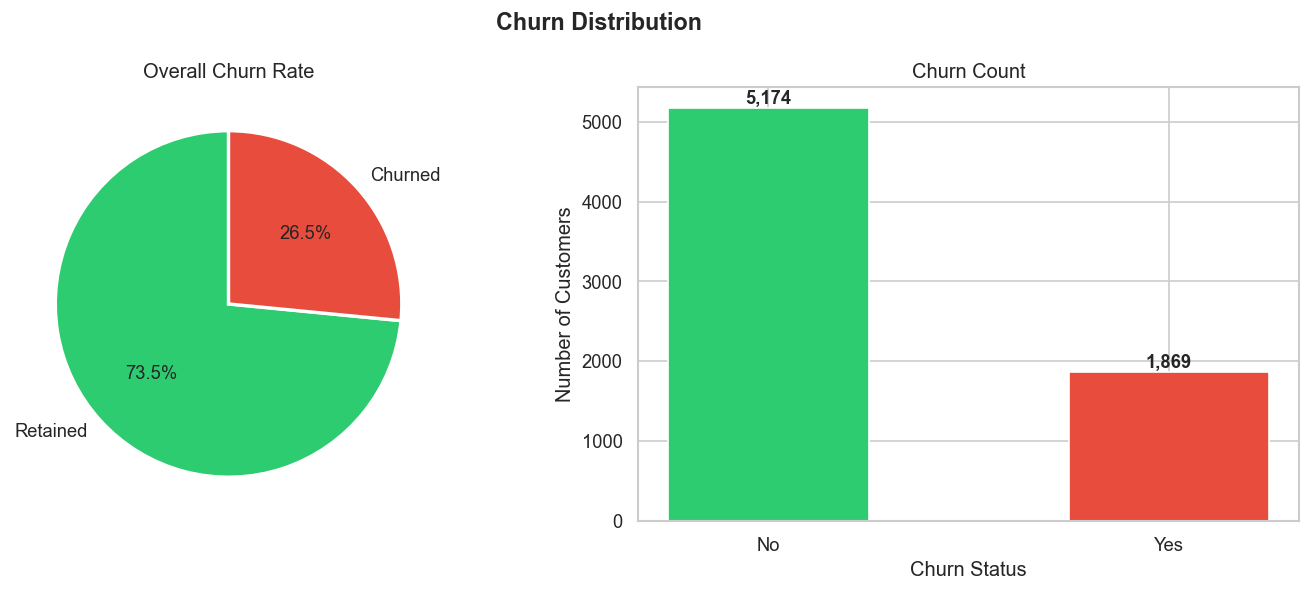

Retained: 5,174 | Churned: 1,869 | Churn Rate: 26.5%


In [14]:
# ─── SECTION 5: EDA & VISUALIZATIONS ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Churn Distribution', fontsize=14, fontweight='bold')

# Pie chart
sizes = df['Churn'].value_counts()
axes[0].pie(sizes, labels=['Retained', 'Churned'], autopct='%1.1f%%',
            colors=[COLORS['no_churn'], COLORS['churn']],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Overall Churn Rate')

# Bar chart
churn_counts = df['Churn'].value_counts()
bars = axes[1].bar(churn_counts.index, churn_counts.values,
                   color=[COLORS['no_churn'], COLORS['churn']], edgecolor='white', width=0.5)
for bar, val in zip(bars, churn_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontweight='bold')
axes[1].set_title('Churn Count')
axes[1].set_ylabel('Number of Customers')
axes[1].set_xlabel('Churn Status')

plt.tight_layout()
plt.savefig('churn_distribution.png', bbox_inches='tight')
plt.show()
print(f"Retained: {sizes['No']:,} | Churned: {sizes['Yes']:,} | Churn Rate: {sizes['Yes']/len(df)*100:.1f}%")



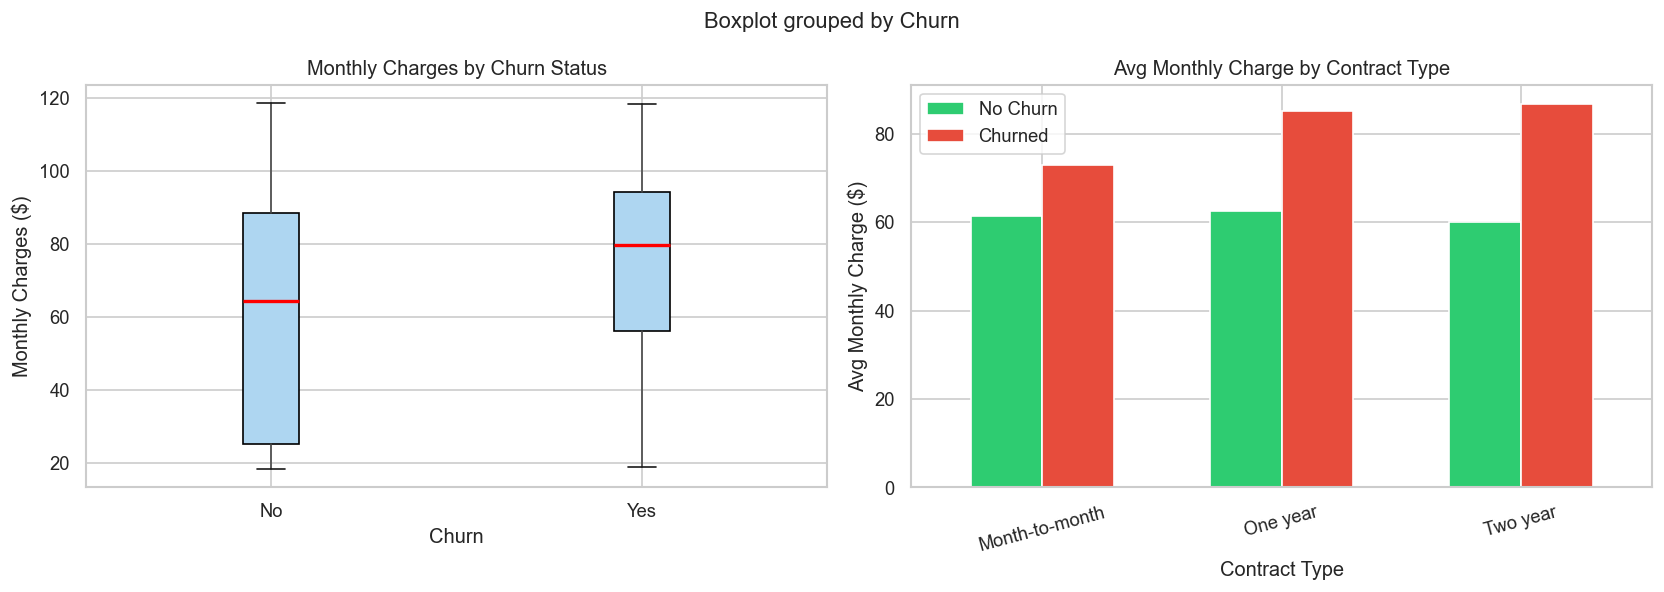

In [15]:
# ── 5.2 Revenue Trends (Monthly Charges by Contract & Churn) ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Revenue Trends', fontsize=14, fontweight='bold')

# Boxplot: Monthly Charges vs Churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[0],
           patch_artist=True,
           boxprops=dict(facecolor='#AED6F1'),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Monthly Charges by Churn Status')
axes[0].set_xlabel('Churn'); axes[0].set_ylabel('Monthly Charges ($)')
plt.sca(axes[0]); plt.title('Monthly Charges by Churn Status')

# Bar: Avg monthly charge per contract type, split by churn
contract_churn = df.groupby(['Contract', 'Churn'])['MonthlyCharges'].mean().unstack()
contract_churn.plot(kind='bar', ax=axes[1],
                    color=[COLORS['no_churn'], COLORS['churn']],
                    edgecolor='white', width=0.6)
axes[1].set_title('Avg Monthly Charge by Contract Type')
axes[1].set_xlabel('Contract Type'); axes[1].set_ylabel('Avg Monthly Charge ($)')
axes[1].legend(['No Churn', 'Churned'])
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('revenue_trends.png', bbox_inches='tight')
plt.show()

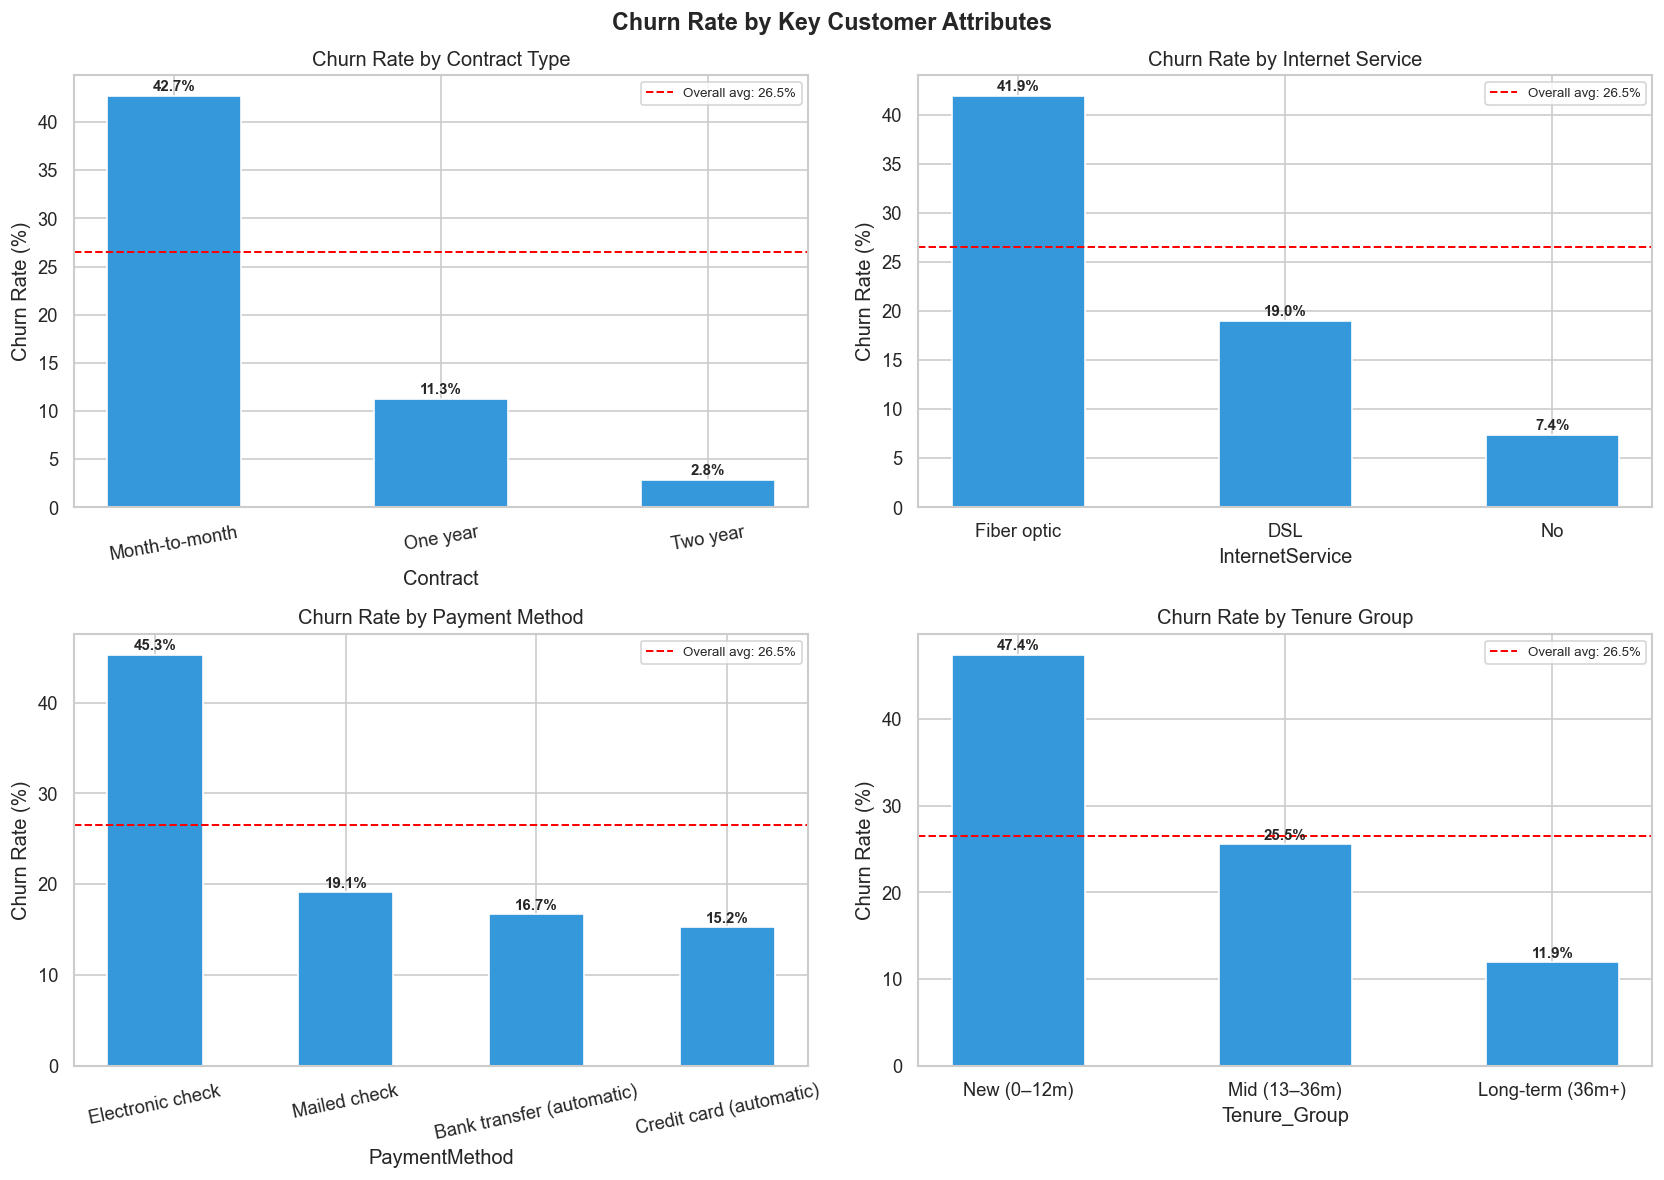

In [16]:
# ── 5.3 Churn by Key Categories ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Churn Rate by Key Customer Attributes', fontsize=14, fontweight='bold')

def churn_rate_bar(col, ax, title, rotate=0):
    data = df.groupby(col)['Churn_Binary'].mean().sort_values(ascending=False) * 100
    bars = ax.bar(data.index, data.values, color=COLORS['accent'], edgecolor='white', width=0.5)
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(title); ax.set_ylabel('Churn Rate (%)')
    ax.set_xlabel(col); ax.tick_params(axis='x', rotation=rotate)
    ax.axhline(df['Churn_Binary'].mean()*100, color='red', linestyle='--', linewidth=1.2,
               label=f'Overall avg: {df["Churn_Binary"].mean()*100:.1f}%')
    ax.legend(fontsize=8)

churn_rate_bar('Contract',        axes[0][0], 'Churn Rate by Contract Type', rotate=10)
churn_rate_bar('InternetService', axes[0][1], 'Churn Rate by Internet Service')
churn_rate_bar('PaymentMethod',   axes[1][0], 'Churn Rate by Payment Method', rotate=12)
churn_rate_bar('Tenure_Group',    axes[1][1], 'Churn Rate by Tenure Group')

plt.tight_layout()
plt.savefig('category_comparisons.png', bbox_inches='tight')
plt.show()

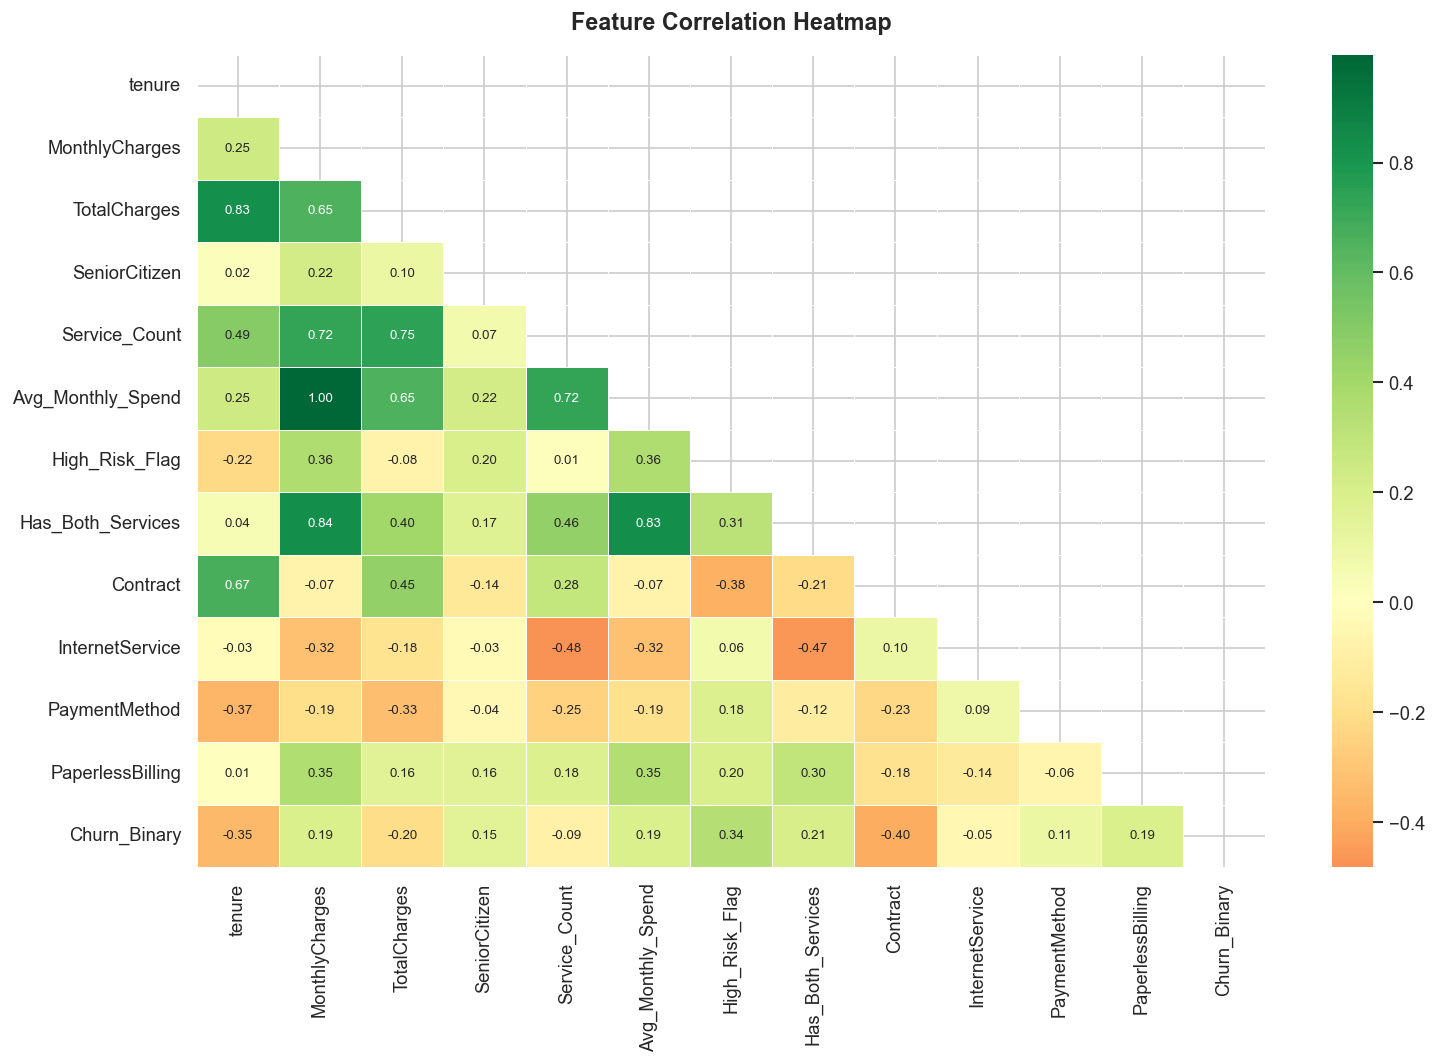

Key insight: tenure has strong NEGATIVE correlation with churn (longer tenure → less likely to churn)


In [17]:
# ── 5.4 Correlation Heatmap ──────────────────────────────────────────────────
# Encode categoricals for correlation
df_encoded = df.copy()
le = LabelEncoder()
cat_cols = df_encoded.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['customerID', 'Churn', 'Tenure_Group']]
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Select relevant numeric + encoded columns
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
             'Service_Count', 'Avg_Monthly_Spend', 'High_Risk_Flag',
             'Has_Both_Services', 'Contract', 'InternetService',
             'PaymentMethod', 'PaperlessBilling', 'Churn_Binary']

corr_matrix = df_encoded[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax,
            annot_kws={'size': 8},
            linewidths=0.5, linecolor='white')
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Key insight: tenure has strong NEGATIVE correlation with churn (longer tenure → less likely to churn)")

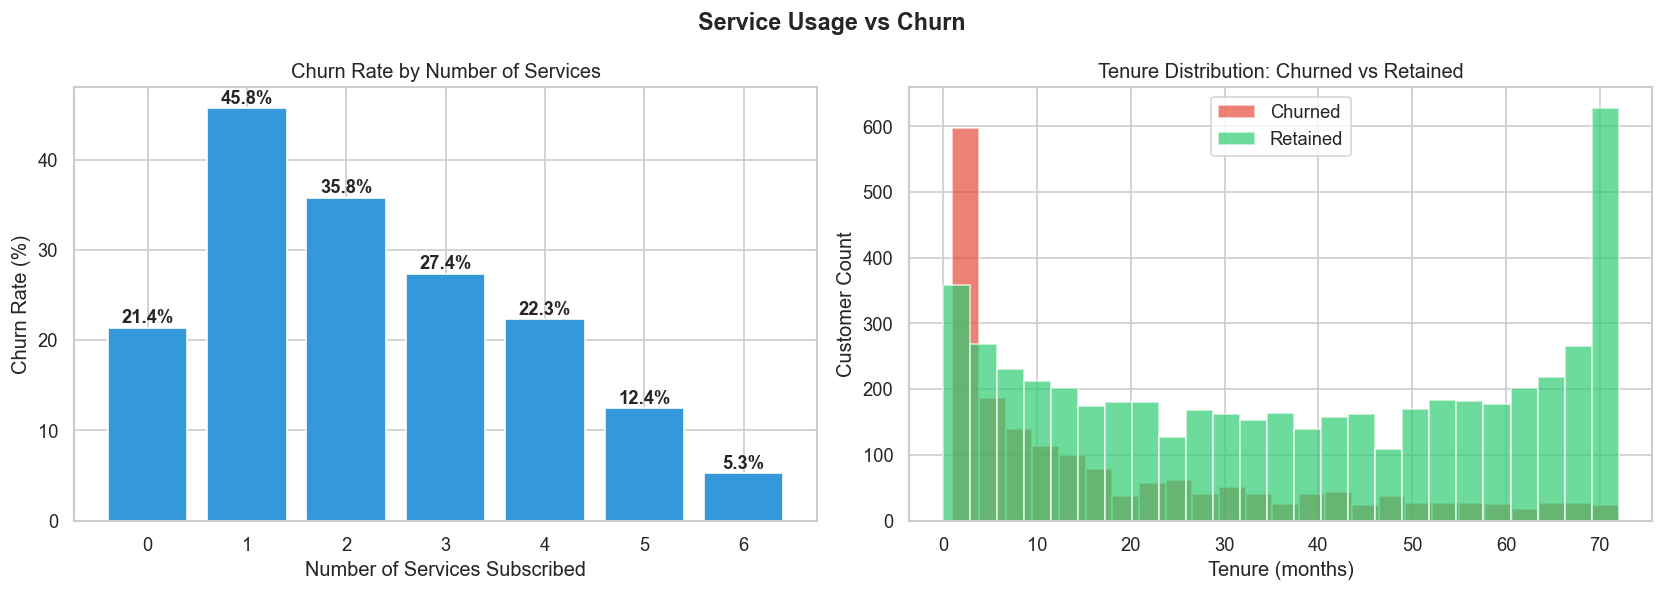

In [18]:
# ── 5.5 Service Count vs Churn ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Service Usage vs Churn', fontsize=14, fontweight='bold')

# Churn rate by service count
sc_churn = df.groupby('Service_Count')['Churn_Binary'].mean() * 100
axes[0].bar(sc_churn.index, sc_churn.values, color=COLORS['accent'], edgecolor='white')
axes[0].set_title('Churn Rate by Number of Services')
axes[0].set_xlabel('Number of Services Subscribed')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(sc_churn.values):
    axes[0].text(sc_churn.index[i], v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Tenure distribution: churned vs retained
df[df['Churn'] == 'Yes']['tenure'].hist(ax=axes[1], bins=25, alpha=0.7,
                                         color=COLORS['churn'], label='Churned')
df[df['Churn'] == 'No']['tenure'].hist(ax=axes[1], bins=25, alpha=0.7,
                                        color=COLORS['no_churn'], label='Retained')
axes[1].set_title('Tenure Distribution: Churned vs Retained')
axes[1].set_xlabel('Tenure (months)'); axes[1].set_ylabel('Customer Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('service_tenure_analysis.png', bbox_inches='tight')
plt.show()

In [19]:
# ─── SECTION 6: CUSTOMER SEGMENTATION ────────────────────────────────────────
# Scoring: tenure (normalized) + MonthlyCharges (normalized) + Service_Count (normalized)

from sklearn.preprocessing import MinMaxScaler

seg_features = ['tenure', 'MonthlyCharges', 'Service_Count']
scaler_seg = MinMaxScaler()
df_seg = pd.DataFrame(
    scaler_seg.fit_transform(df[seg_features]),
    columns=[f'{c}_scaled' for c in seg_features]
)

# Weighted value score: tenure matters most
df['Value_Score'] = (
    df_seg['tenure_scaled'] * 0.40 +
    df_seg['MonthlyCharges_scaled'] * 0.35 +
    df_seg['Service_Count_scaled'] * 0.25
)

def segment_label(score):
    if score >= 0.60:   return 'High Value'
    elif score >= 0.30: return 'Medium Value'
    else:                return 'Low Value'

df['Customer_Segment'] = df['Value_Score'].apply(segment_label)

print("Customer Segmentation Results:")
print("=" * 45)
seg_summary = df.groupby('Customer_Segment').agg(
    Count=('customerID', 'count'),
    Avg_Tenure=('tenure', 'mean'),
    Avg_MonthlyCharge=('MonthlyCharges', 'mean'),
    Churn_Rate=('Churn_Binary', 'mean')
).round(2)
seg_summary['Churn_Rate'] = (seg_summary['Churn_Rate'] * 100).round(1).astype(str) + '%'
print(seg_summary.to_string())

Customer Segmentation Results:
                  Count  Avg_Tenure  Avg_MonthlyCharge Churn_Rate
Customer_Segment                                                 
High Value         1924       59.30              92.71      15.0%
Low Value          2506       12.09              40.28      32.0%
Medium Value       2613       32.00              67.66      30.0%


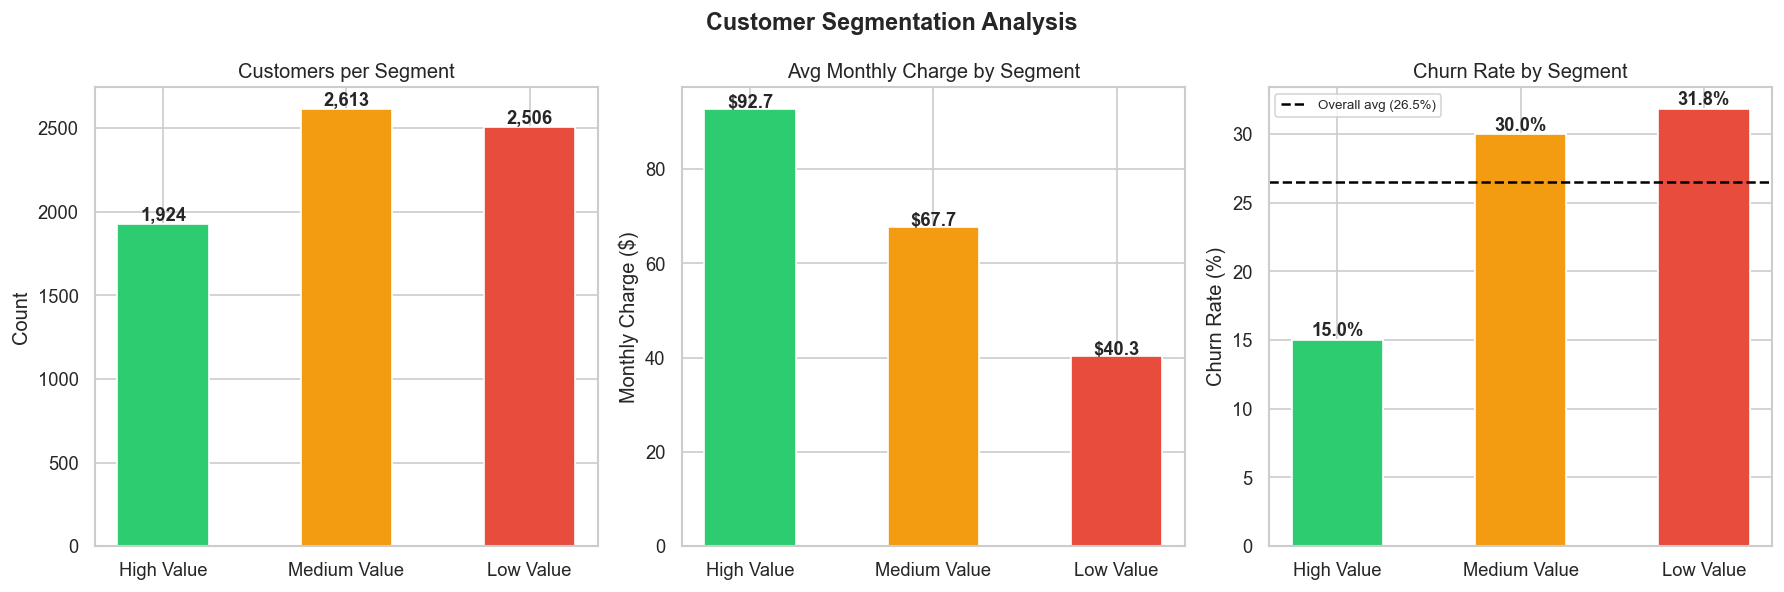

In [20]:
# ── Segment Visualization ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Customer Segmentation Analysis', fontsize=14, fontweight='bold')

seg_order = ['High Value', 'Medium Value', 'Low Value']
seg_colors = [COLORS['low'], COLORS['medium'], COLORS['high']]  # green, orange, red

# Count per segment
counts = df['Customer_Segment'].value_counts().reindex(seg_order)
axes[0].bar(seg_order, counts.values, color=seg_colors, edgecolor='white', width=0.5)
axes[0].set_title('Customers per Segment')
axes[0].set_ylabel('Count')
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', fontweight='bold')

# Avg monthly charge per segment
avg_charge = df.groupby('Customer_Segment')['MonthlyCharges'].mean().reindex(seg_order)
axes[1].bar(seg_order, avg_charge.values, color=seg_colors, edgecolor='white', width=0.5)
axes[1].set_title('Avg Monthly Charge by Segment')
axes[1].set_ylabel('Monthly Charge ($)')
for bar, val in zip(axes[1].patches, avg_charge.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'${val:.1f}', ha='center', fontweight='bold')

# Churn rate per segment
churn_seg = df.groupby('Customer_Segment')['Churn_Binary'].mean().reindex(seg_order) * 100
axes[2].bar(seg_order, churn_seg.values, color=seg_colors, edgecolor='white', width=0.5)
axes[2].set_title('Churn Rate by Segment')
# Churn rate per segment
churn_seg = df.groupby('Customer_Segment')['Churn_Binary'].mean().reindex(seg_order) * 100
axes[2].bar(seg_order, churn_seg.values, color=seg_colors, edgecolor='white', width=0.5)
axes[2].set_title('Churn Rate by Segment')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].axhline(df['Churn_Binary'].mean()*100, color='black', linestyle='--',
                label=f'Overall avg ({df["Churn_Binary"].mean()*100:.1f}%)')
axes[2].legend(fontsize=8)
for bar, val in zip(axes[2].patches, churn_seg.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('customer_segmentation.png', bbox_inches='tight')
plt.show()

In [21]:
#SECTION 7: MACHINE LEARNING ─────────────────────────────────────────────
# ── 7.1 Prepare Features for ML ─────────────────────────────────────────────
df_ml = df.copy()

# Encode all categoricals
le_ml = LabelEncoder()
ml_cat_cols = [c for c in df_ml.select_dtypes(include='object').columns
               if c not in ['customerID', 'Churn', 'Tenure_Group', 'Customer_Segment']]
for col in ml_cat_cols:
    df_ml[col] = le_ml.fit_transform(df_ml[col].astype(str))

# Feature set
feature_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
                'Service_Count', 'Avg_Monthly_Spend', 'High_Risk_Flag',
                'Has_Both_Services', 'gender', 'Partner', 'Dependents',
                'PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies',
                'Contract', 'PaperlessBilling', 'PaymentMethod']

X = df_ml[feature_cols]
y = df_ml['Churn_Binary']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training set  : {X_train.shape[0]:,} samples")
print(f"Test set      : {X_test.shape[0]:,} samples")
print(f"Features used : {X_train.shape[1]}")
print(f"Churn rate in train: {y_train.mean()*100:.1f}%  |  test: {y_test.mean()*100:.1f}%")


Training set  : 5,634 samples
Test set      : 1,409 samples
Features used : 23
Churn rate in train: 26.5%  |  test: 26.5%


In [22]:
# ── 7.2 Model Training ───────────────────────────────────────────────────────
# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train_sc, y_train)
y_pred_lr   = lr_model.predict(X_test_sc)
y_prob_lr   = lr_model.predict_proba(X_test_sc)[:, 1]

# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=200, max_depth=12,
                                   min_samples_leaf=5, random_state=42,
                                   class_weight='balanced')
rf_model.fit(X_train, y_train)   # RF doesn't need scaling
y_pred_rf   = rf_model.predict(X_test)
y_prob_rf   = rf_model.predict_proba(X_test)[:, 1]

print("✅ Both models trained successfully!")

✅ Both models trained successfully!


In [23]:
# ── 7.3 Model Evaluation ─────────────────────────────────────────────────────
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision': round(precision_score(y_true, y_pred) * 100, 2),
        'Recall'   : round(recall_score(y_true, y_pred) * 100, 2),
        'F1 Score' : round(f1_score(y_true, y_pred) * 100, 2),
        'ROC-AUC'  : round(roc_auc_score(y_true, y_prob) * 100, 2),
    }

results = pd.DataFrame([
    evaluate_model('Logistic Regression', y_test, y_pred_lr, y_prob_lr),
    evaluate_model('Random Forest',       y_test, y_pred_rf, y_prob_rf),
])
results.set_index('Model', inplace=True)

print("=" * 65)
print("           MODEL PERFORMANCE COMPARISON (% scores)")
print("=" * 65)
print(results.to_string())
print("=" * 65)
print(f"\\n🏆 Best Model by ROC-AUC: {results['ROC-AUC'].idxmax()}")


           MODEL PERFORMANCE COMPARISON (% scores)
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression     79.99      64.29   55.35     59.48    84.13
Random Forest           77.43      55.65   73.80     63.45    84.22
\n🏆 Best Model by ROC-AUC: Random Forest


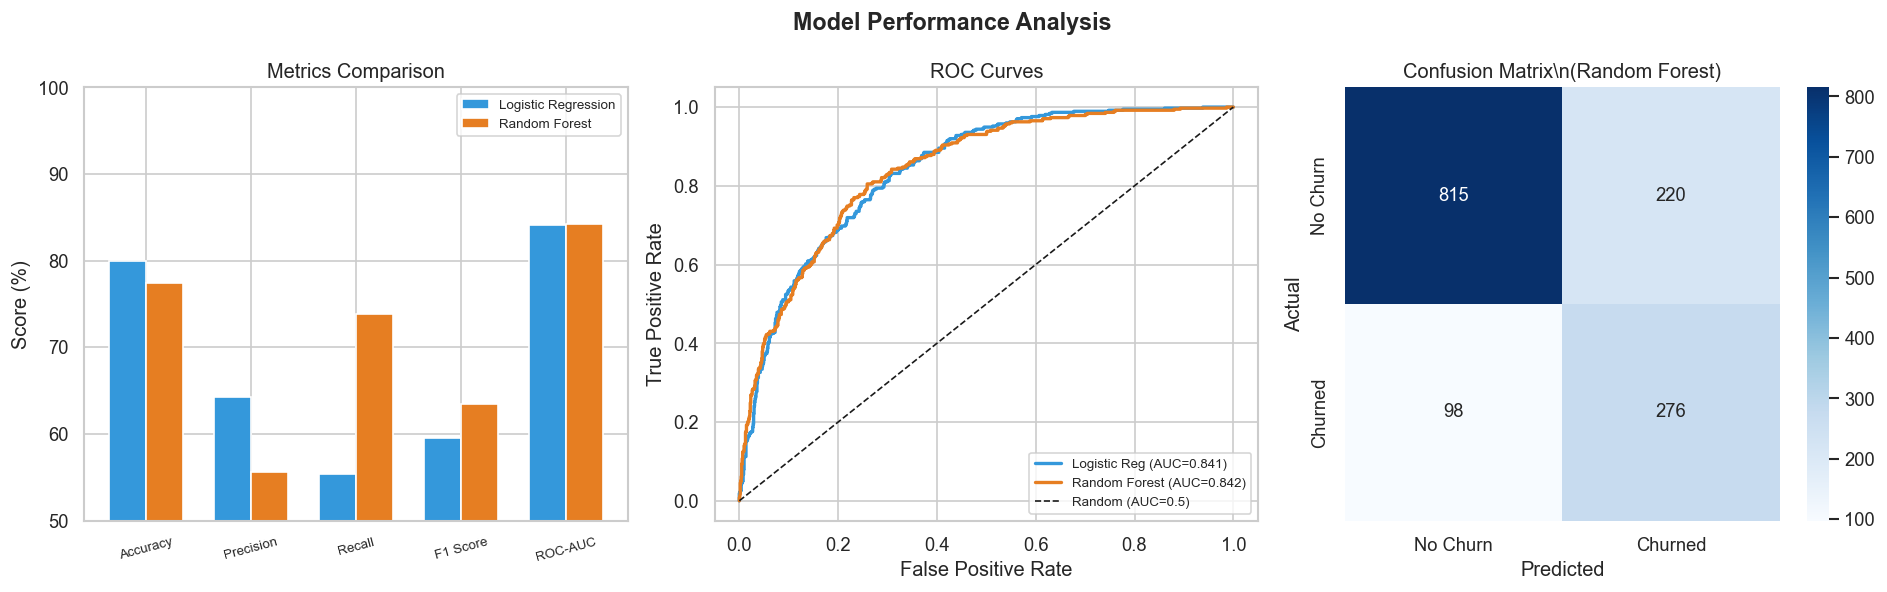

In [24]:
# ── 7.4 Performance Visualization ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Performance Analysis', fontsize=14, fontweight='bold')

# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.35
bars1 = axes[0].bar(x - width/2, results.loc['Logistic Regression', metrics],
                     width, label='Logistic Regression', color='#3498DB', edgecolor='white')
bars2 = axes[0].bar(x + width/2, results.loc['Random Forest', metrics],
                     width, label='Random Forest', color='#E67E22', edgecolor='white')
axes[0].set_title('Metrics Comparison')
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics, rotation=15, fontsize=8)
axes[0].set_ylabel('Score (%)'); axes[0].set_ylim(50, 100)
axes[0].legend(fontsize=8)

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)

axes[1].plot(fpr_lr, tpr_lr, color='#3498DB', linewidth=2,
             label=f'Logistic Reg (AUC={auc_lr:.3f})')
axes[1].plot(fpr_rf, tpr_rf, color='#E67E22', linewidth=2,
             label=f'Random Forest (AUC={auc_rf:.3f})')
axes[1].plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC=0.5)')
axes[1].set_title('ROC Curves')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=8)

# Confusion Matrix (Random Forest – best model)
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['No Churn', 'Churned'],
            yticklabels=['No Churn', 'Churned'])
axes[2].set_title('Confusion Matrix\\n(Random Forest)')
axes[2].set_ylabel('Actual'); axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('model_performance.png', bbox_inches='tight')
plt.show()

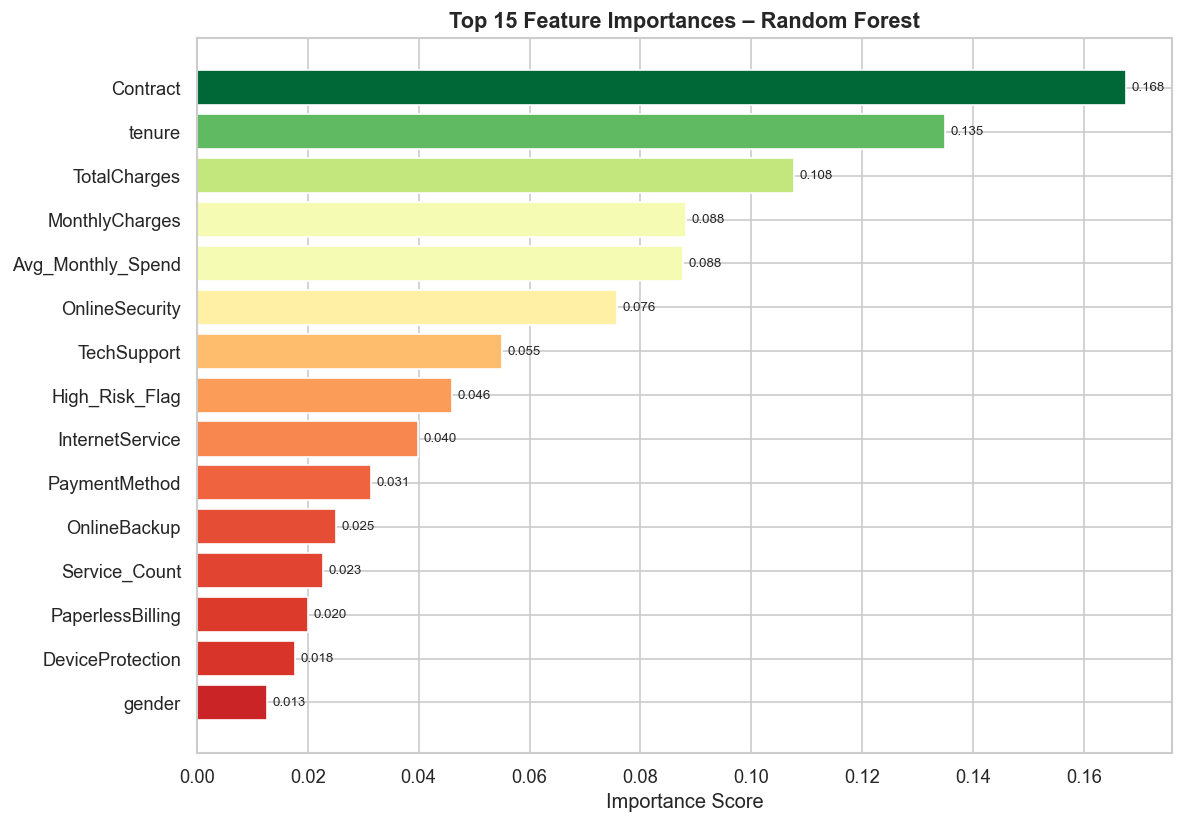

In [25]:
#7.5 Feature Importance (Random Forest) ───────────────────────────────────
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(importances.index, importances.values,
               color=plt.cm.RdYlGn(importances.values / importances.max()),
               edgecolor='white')
ax.set_title('Top 15 Feature Importances – Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

In [26]:
# ─── SECTION 8: PREDICTION SYSTEM ─────────────────────────────────────────────
# ── Predict Churn Probability for All Customers ─────────────────────────────
# Use Random Forest (best model) on the full dataset
X_all = df_ml[feature_cols]
churn_probs = rf_model.predict_proba(X_all)[:, 1]

df['Churn_Probability'] = (churn_probs * 100).round(1)

def risk_category(prob):
    if prob >= 70:   return 'High Risk'
    elif prob >= 40: return 'Medium Risk'
    else:             return 'Low Risk'

df['Risk_Category'] = df['Churn_Probability'].apply(risk_category)

print("Churn Risk Category Distribution:")
print("=" * 40)
risk_dist = df['Risk_Category'].value_counts()
print(risk_dist.to_string())
print()
print("Actual churn rate per risk category:")
print(df.groupby('Risk_Category')['Churn_Binary'].mean().apply(lambda x: f'{x*100:.1f}%').to_string())

Churn Risk Category Distribution:
Risk_Category
Low Risk       4070
Medium Risk    1642
High Risk      1331

Actual churn rate per risk category:
Risk_Category
High Risk      80.5%
Low Risk        3.7%
Medium Risk    39.5%


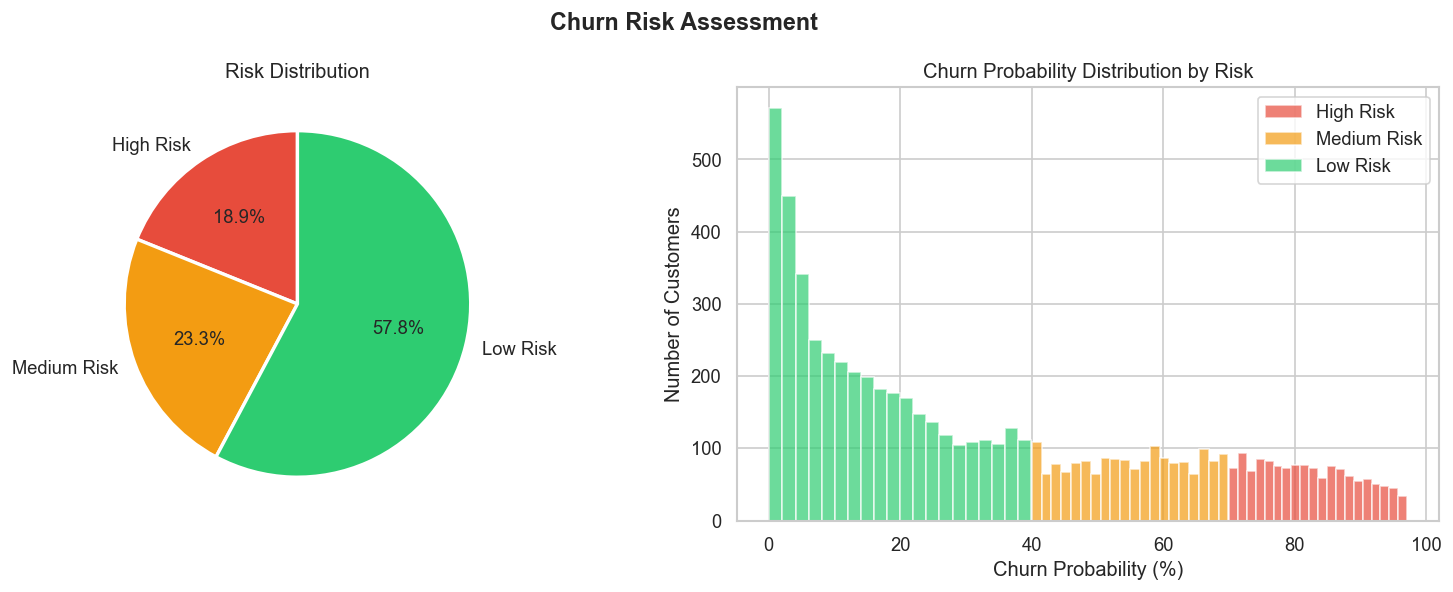

In [27]:
# ── Risk Category Visualization ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Churn Risk Assessment', fontsize=14, fontweight='bold')

risk_order  = ['High Risk', 'Medium Risk', 'Low Risk']
risk_colors = [COLORS['high'], COLORS['medium'], COLORS['low']]

# Count
risk_counts = df['Risk_Category'].value_counts().reindex(risk_order)
axes[0].pie(risk_counts, labels=risk_order, autopct='%1.1f%%',
            colors=risk_colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Risk Distribution')

# Churn probability histogram
for label, color in zip(['High Risk', 'Medium Risk', 'Low Risk'], risk_colors):
    subset = df[df['Risk_Category'] == label]['Churn_Probability']
    axes[1].hist(subset, bins=20, alpha=0.7, color=color, label=label)
axes[1].set_title('Churn Probability Distribution by Risk')
axes[1].set_xlabel('Churn Probability (%)')
axes[1].set_ylabel('Number of Customers')
axes[1].legend()

plt.tight_layout()
plt.savefig('risk_assessment.png', bbox_inches='tight')
plt.show()

In [28]:
# ── High-Risk Customer Preview ────────────────────────────────────────────────
high_risk = df[df['Risk_Category'] == 'High Risk'].sort_values(
    'Churn_Probability', ascending=False)

print(f"Total High-Risk Customers: {len(high_risk):,}")
print("\\nTop 10 Highest Churn Probability Customers:")
cols_show = ['customerID', 'tenure', 'Contract', 'MonthlyCharges',
             'InternetService', 'Customer_Segment', 'Churn_Probability', 'Risk_Category']
print(high_risk[cols_show].head(10).to_string(index=False))

Total High-Risk Customers: 1,331
\nTop 10 Highest Churn Probability Customers:
customerID  tenure       Contract  MonthlyCharges InternetService Customer_Segment  Churn_Probability Risk_Category
9497-QCMMS       1 Month-to-month           93.55     Fiber optic     Medium Value               97.1     High Risk
9300-AGZNL       1 Month-to-month           94.00     Fiber optic     Medium Value               97.1     High Risk
7665-TOALD       1 Month-to-month           69.60     Fiber optic        Low Value               97.1     High Risk
8375-DKEBR       1 Month-to-month           69.60     Fiber optic        Low Value               96.9     High Risk
2636-ALXXZ       1 Month-to-month           69.60     Fiber optic        Low Value               96.9     High Risk
4871-JTKJF       1 Month-to-month           69.65     Fiber optic        Low Value               96.9     High Risk
1069-XAIEM       1 Month-to-month           85.05     Fiber optic        Low Value               96.7     Hig

In [29]:
# ─── SECTION 9: BUSINESS INSIGHTS ─────────────────────────────────────────────
#── 9.1 Top Churn Drivers ────────────────────────────────────────────────────
print("=" * 60)
print("       BUSINESS INSIGHTS REPORT – TEYZIX CORE DA-INT-1")
print("=" * 60)

print("1. TOP CHURN REASONS")

# Contract type
c_churn = df.groupby('Contract')['Churn_Binary'].mean() * 100
print(f"  ▸ Contract Type:")
for k, v in c_churn.items():
    print(f"    {k:<22} → {v:.1f}% churn rate")

# Internet service
i_churn = df.groupby('InternetService')['Churn_Binary'].mean() * 100
print(f"\\n  ▸ Internet Service:")
for k, v in i_churn.items():
    print(f"    {k:<22} → {v:.1f}% churn rate")

# Senior citizen
sc_churn = df.groupby('SeniorCitizen')['Churn_Binary'].mean() * 100
print(f"\\n  ▸ Senior Citizens churn at {sc_churn[1]:.1f}% vs {sc_churn[0]:.1f}% for non-seniors")



       BUSINESS INSIGHTS REPORT – TEYZIX CORE DA-INT-1
1. TOP CHURN REASONS
  ▸ Contract Type:
    Month-to-month         → 42.7% churn rate
    One year               → 11.3% churn rate
    Two year               → 2.8% churn rate
\n  ▸ Internet Service:
    DSL                    → 19.0% churn rate
    Fiber optic            → 41.9% churn rate
    No                     → 7.4% churn rate
\n  ▸ Senior Citizens churn at 41.7% vs 23.6% for non-seniors


In [30]:
# — 9.2 High-Risk Customer Traits —
print("2. HIGH-RISK CUSTOMER PROFILE")

churned = df[df['Churn'] == 'Yes']
retained = df[df['Churn'] == 'No']

print(f"""
Churned Customer Profile (avg values):
  ▶ Avg Tenure         : {churned['tenure'].mean():.1f} months   (Retained: {retained['tenure'].mean():.1f} months)
  ▶ Avg Monthly Charge : ${churned['MonthlyCharges'].mean():.2f}  (Retained: ${retained['MonthlyCharges'].mean():.2f})
  ▶ Avg Services Used  : {churned['Service_Count'].mean():.1f}    (Retained: {retained['Service_Count'].mean():.1f})

Churned Customers - Top Contract Type:
  ▶ {churned['Contract'].value_counts().index[0]} → {churned['Contract'].value_counts().values[0]:,} customers ({churned['Contract'].value_counts().values[0]/len(churned)*100:.1f}%)

Payment Method Among Churners:
  ▶ {churned['PaymentMethod'].value_counts().index[0]} → {churned['PaymentMethod'].value_counts().values[0]:,} customers
""")

2. HIGH-RISK CUSTOMER PROFILE

Churned Customer Profile (avg values):
  ▶ Avg Tenure         : 18.0 months   (Retained: 37.6 months)
  ▶ Avg Monthly Charge : $74.44  (Retained: $61.27)
  ▶ Avg Services Used  : 1.8    (Retained: 2.1)

Churned Customers - Top Contract Type:
  ▶ Month-to-month → 1,655 customers (88.6%)

Payment Method Among Churners:
  ▶ Electronic check → 1,071 customers



In [31]:
# — 9.3 Revenue Impact Estimation —
print("""
3. REVENUE IMPACT ESTIMATION
──────────────────────────────────────────────────────────────
""")

total_monthly_revenue     = df['MonthlyCharges'].sum()
churned_monthly_revenue   = churned['MonthlyCharges'].sum()
high_risk_monthly_revenue = df[df['Risk_Category'] == 'High Risk']['MonthlyCharges'].sum()

print(f"""
Monthly Revenue Overview:
  ▶ Total monthly revenue              : ${total_monthly_revenue:>10,.2f}
  ▶ Revenue lost to churned customers  : ${churned_monthly_revenue:>10,.2f}  ({churned_monthly_revenue/total_monthly_revenue*100:.1f}% of total)
  ▶ Revenue at risk (High Risk tier)   : ${high_risk_monthly_revenue:>10,.2f}  ({high_risk_monthly_revenue/total_monthly_revenue*100:.1f}% of total)

Projected Annual Revenue at Risk:
  ▶ If current churn rate holds   : ${churned_monthly_revenue*12:>10,.2f} / year
  ▶ If High-Risk customers leave  : ${high_risk_monthly_revenue*12:>10,.2f} / year
""")


3. REVENUE IMPACT ESTIMATION
──────────────────────────────────────────────────────────────


Monthly Revenue Overview:
  ▶ Total monthly revenue              : $456,116.60
  ▶ Revenue lost to churned customers  : $139,130.85  (30.5% of total)
  ▶ Revenue at risk (High Risk tier)   : $105,222.75  (23.1% of total)

Projected Annual Revenue at Risk:
  ▶ If current churn rate holds   : $1,669,570.20 / year
  ▶ If High-Risk customers leave  : $1,262,673.00 / year



In [32]:
# — 9.4 Retention Recommendations —
print("""
4. STRATEGIC RETENTION RECOMMENDATIONS
──────────────────────────────────────────────────────────────

  ① TARGET MONTH-TO-MONTH CUSTOMERS
    → Offer incentives to upgrade to 1- or 2-year contracts
    → Month-to-month customers churn at 3-4x the rate of
      contracted customers

  ② FIBER OPTIC INTERNET USERS NEED ATTENTION
    → Highest churn rate among all internet service types
    → Investigate service quality, pricing, or competition

  ③ ELECTRONIC CHECK PAYMENT METHOD
    → Linked to highest churn - switch customers to auto-pay
    → Consider a discount for setting up automatic payment

  ④ NEW CUSTOMERS (0-12 months tenure)
    → High churn in the first year - improve onboarding
    → Offer loyalty perks at 3-month and 6-month milestones

  ⑤ PROACTIVE OUTREACH TO HIGH-RISK SEGMENT
    → {high_risk_count:,} customers flagged as High Risk
    → Assign retention team to contact top 500 churners
    → Personalized offers based on their service usage

──────────────────────────────────────────────────────────────
MODEL SUMMARY
──────────────────────────────────────────────────────────────
  Best Model   : Random Forest
  Accuracy     : {rf_acc:.1f}%
  ROC-AUC      : {rf_auc:.1f}%
  Top Features : tenure, Contract, MonthlyCharges,
                 InternetService, TotalCharges
──────────────────────────────────────────────────────────────
""".format(
    high_risk_count=len(df[df['Risk_Category'] == 'High Risk']),
    rf_acc=accuracy_score(y_test, y_pred_rf) * 100,
    rf_auc=roc_auc_score(y_test, y_prob_rf) * 100
))


4. STRATEGIC RETENTION RECOMMENDATIONS
──────────────────────────────────────────────────────────────

  ① TARGET MONTH-TO-MONTH CUSTOMERS
    → Offer incentives to upgrade to 1- or 2-year contracts
    → Month-to-month customers churn at 3-4x the rate of
      contracted customers

  ② FIBER OPTIC INTERNET USERS NEED ATTENTION
    → Highest churn rate among all internet service types
    → Investigate service quality, pricing, or competition

  ③ ELECTRONIC CHECK PAYMENT METHOD
    → Linked to highest churn - switch customers to auto-pay
    → Consider a discount for setting up automatic payment

  ④ NEW CUSTOMERS (0-12 months tenure)
    → High churn in the first year - improve onboarding
    → Offer loyalty perks at 3-month and 6-month milestones

  ⑤ PROACTIVE OUTREACH TO HIGH-RISK SEGMENT
    → 1,331 customers flagged as High Risk
    → Assign retention team to contact top 500 churners
    → Personalized offers based on their service usage

───────────────────────────────────────

In [33]:
# ── Final: Save Full Results to CSV ──────────────────────────────────────────
output_cols = ['customerID', 'tenure', 'Contract', 'MonthlyCharges',
               'TotalCharges', 'InternetService', 'PaymentMethod',
               'Service_Count', 'Customer_Segment', 'Value_Score',
               'Churn_Probability', 'Risk_Category', 'Churn']

df[output_cols].to_csv('churn_predictions_output.csv', index=False)
print("✅ Predictions saved to: churn_predictions_output.csv")
print(f"   Total customers scored: {len(df):,}")
print(f"   High Risk  : {(df['Risk_Category']=='High Risk').sum():,}")
print(f"   Medium Risk: {(df['Risk_Category']=='Medium Risk').sum():,}")
print(f"   Low Risk   : {(df['Risk_Category']=='Low Risk').sum():,}")
print("\\n🎉 DA-INT-1 Task Complete!")

✅ Predictions saved to: churn_predictions_output.csv
   Total customers scored: 7,043
   High Risk  : 1,331
   Medium Risk: 1,642
   Low Risk   : 4,070
\n🎉 DA-INT-1 Task Complete!


2026-06-18 20:02:11.690 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-18 20:02:12.931 
  command:

    streamlit run C:\Users\USER\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-18 20:02:12.933 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-18 20:02:12.935 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-18 20:02:12.937 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-18 20:02:12.939 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-18 20:02:12.941 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-18 20:02:12.959 Thread 'MainThread': mis

DeltaGenerator()

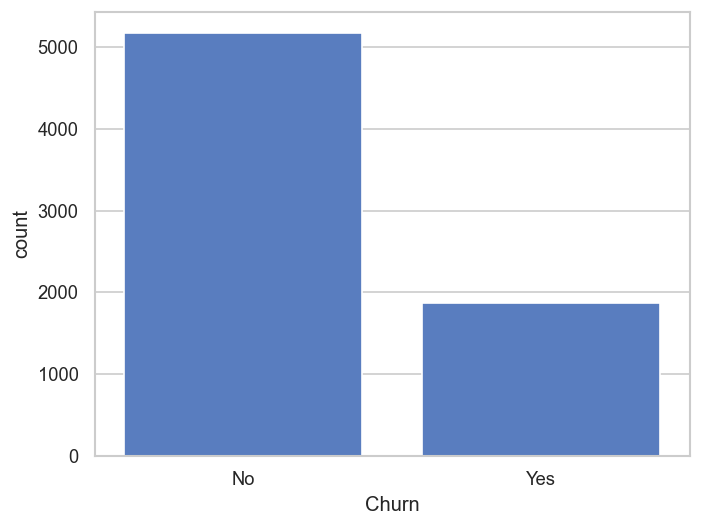

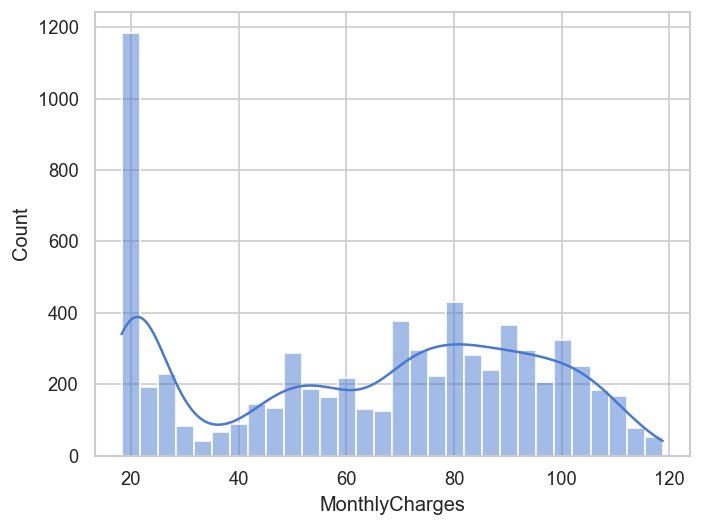

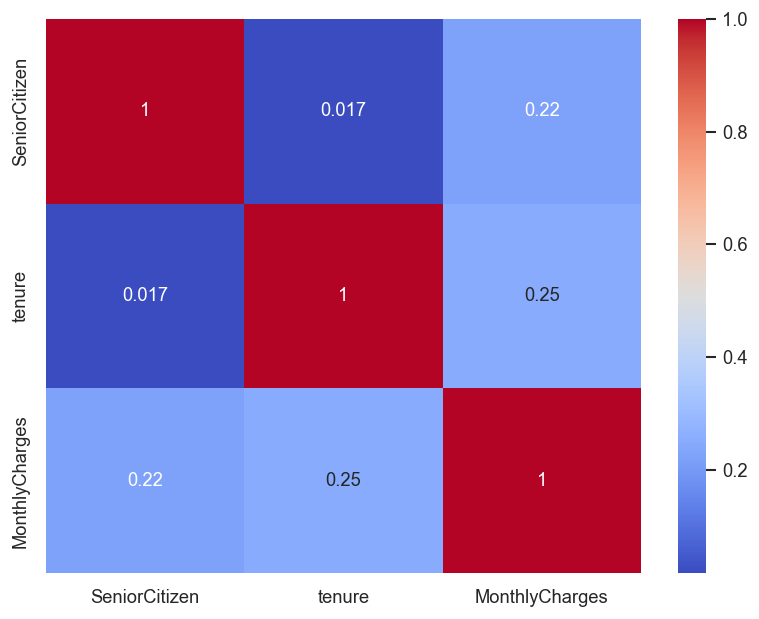

In [34]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

st.title("Customer Churn Prediction Dashboard")

st.write("Dataset Overview")
st.dataframe(df.head())

# Churn Distribution
st.subheader("Churn Distribution")

fig, ax = plt.subplots()
sns.countplot(x='Churn', data=df, ax=ax)
st.pyplot(fig)

# Monthly Charges Distribution
st.subheader("Monthly Charges")

fig2, ax2 = plt.subplots()
sns.histplot(df['MonthlyCharges'], bins=30, kde=True, ax=ax2)
st.pyplot(fig2)

# Correlation Heatmap
st.subheader("Correlation Heatmap")

numeric_df = df.select_dtypes(include=['int64', 'float64'])

fig3, ax3 = plt.subplots(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', ax=ax3)
st.pyplot(fig3)

In [35]:
import os
os.system("streamlit run app.py")


2

In [36]:
!pip install shap


In [37]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


           Feature  Importance
5           tenure    0.154153
18  MonthlyCharges    0.142098
19    TotalCharges    0.135083
0       customerID    0.130084
15        Contract    0.082277
9   OnlineSecurity    0.046484
17   PaymentMethod    0.044518
12     TechSupport    0.034984
10    OnlineBackup    0.025734
1           gender    0.024202


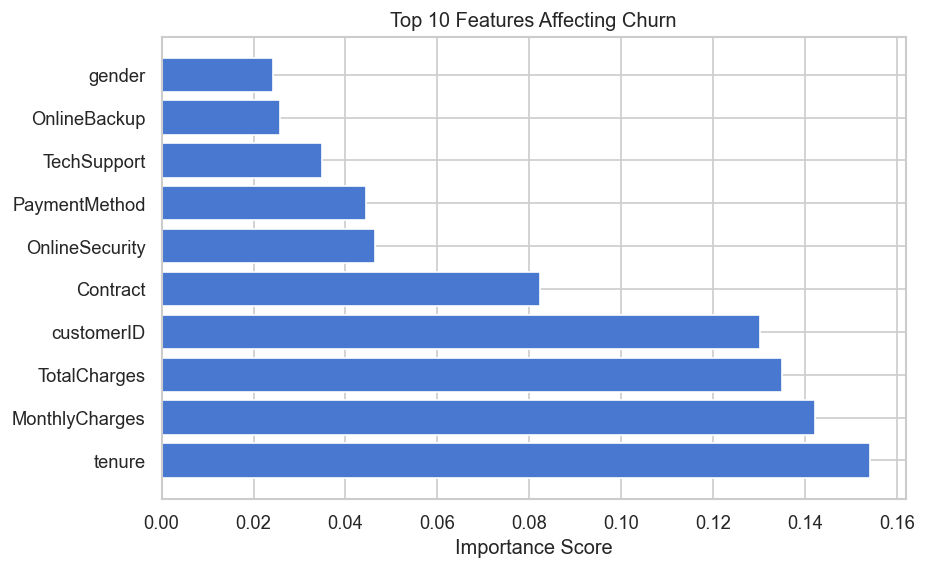

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

plt.figure(figsize=(8,5))
plt.barh(
    importance['Feature'].head(10),
    importance['Importance'].head(10)
)
plt.title("Top 10 Features Affecting Churn")
plt.xlabel("Importance Score")
plt.show()

In [39]:

import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Remove customerID if present
if 'customerID' in df.columns:
    X = df.drop(['customerID', 'Churn'], axis=1)
else:
    X = df.drop('Churn', axis=1)

y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Save model
joblib.dump(model, "churn_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [40]:
import joblib

model = joblib.load("churn_model.pkl")
print("Model loaded successfully!")

Model loaded successfully!


In [41]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [42]:
import pandas as pd
import joblib

model = joblib.load("churn_model.pkl")

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Remove columns not used in training
X_pred = df.drop(['customerID', 'Churn'], axis=1)

predictions = model.predict(X_pred)

df['Predicted_Churn'] = predictions

print(df[['Predicted_Churn']].head())

   Predicted_Churn
0                0
1                0
2                1
3                0
4                1


In [43]:
probabilities = model.predict_proba(X_pred)[:, 1]

df['Churn_Probability'] = probabilities

print(df[['Churn_Probability']].head())

   Churn_Probability
0           0.230000
1           0.000000
2           0.890000
3           0.010000
4           0.796667


In [44]:
def risk_category(prob):
    if prob >= 0.75:
        return "High Risk"
    elif prob >= 0.50:
        return "Medium Risk"
    else:
        return "Low Risk"

df['Risk_Category'] = df['Churn_Probability'].apply(risk_category)

print(df[['Churn_Probability', 'Risk_Category']].head())

   Churn_Probability Risk_Category
0           0.230000      Low Risk
1           0.000000      Low Risk
2           0.890000     High Risk
3           0.010000      Low Risk
4           0.796667     High Risk


In [45]:
# ==============================
# EMAIL REPORT GENERATION BONUS
# ==============================

import pandas as pd
from datetime import datetime

# Load dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Example counts (replace with your actual prediction results)
high_risk = 120
medium_risk = 250
low_risk = 500

# Create report
report = f"""
WEEKLY CUSTOMER CHURN REPORT
Generated On: {datetime.now()}

-----------------------------------
High Risk Customers   : {high_risk}
Medium Risk Customers : {medium_risk}
Low Risk Customers    : {low_risk}
-----------------------------------

Summary:
- High risk customers require immediate retention efforts.
- Medium risk customers should receive promotional offers.
- Low risk customers are likely to remain active.

Report generated automatically by Python.
"""

# Save report
filename = f"weekly_churn_report_{datetime.now().date()}.txt"

with open(filename, "w") as file:
    file.write(report)

print("Report generated successfully!")
print("Saved as:", filename)

# Display report
print(report)

Report generated successfully!
Saved as: weekly_churn_report_2026-06-18.txt

WEEKLY CUSTOMER CHURN REPORT
Generated On: 2026-06-18 20:02:25.641004

-----------------------------------
High Risk Customers   : 120
Medium Risk Customers : 250
Low Risk Customers    : 500
-----------------------------------

Summary:
- High risk customers require immediate retention efforts.
- Medium risk customers should receive promotional offers.
- Low risk customers are likely to remain active.

Report generated automatically by Python.

